In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import numpy as np
from scipy.special import binom
from collections import Counter
from itertools import combinations
from Configurational_model_HO import *
from HO_effective_degree import *

In [2]:
from numba import jit
from numba import njit, prange
from numba.typed import Dict
from numba.core import types
import scipy.sparse as sp
@jit(nopython=True)
def SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters, edges, triangles, fixed_init, t_max, check_interval=100, variance_threshold=1e-4):
    I_runs = []
    S_runs=[]
    times_runs = []
    
    for h in range(iters):
        indddd = fixed_init[h]
        Infected = np.zeros(N)
        Infected[indddd] = 1

        t = 0
        times = [0]
        I = [np.sum(Infected)]
        S=[N-np.sum(Infected)]

        rate_vec = np.zeros(N)

        while t < t_max:
            # Update rate_vec
            rate_vec.fill(0)
            for edge in edges:
                v1, v2 = edge
                if Infected[v1] == 0 and Infected[v2] == 1:
                    rate_vec[v1] += beta1
                elif Infected[v2] == 0 and Infected[v1] == 1:
                    rate_vec[v2] += beta1

            for triangle in triangles:
                n1, n2, n3 = triangle
                if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                    rate_vec[n1] += beta2
                elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                    rate_vec[n2] += beta2
                elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                    rate_vec[n3] += beta2

            rate_vec[Infected == 1] += mu

            total_rate = np.sum(rate_vec)
            if total_rate == 0:
                break

            delay = np.random.exponential(1.0 / total_rate)
            t += delay

            rr = np.random.random()
            cumulative_rate = 0
            for i in range(N):
                cumulative_rate += rate_vec[i] / total_rate
                if rr < cumulative_rate:
                    if Infected[i] == 1:
                        Infected[i] = 0
                    elif Infected[i] == 0:
                        Infected[i] = 1
                    break

            I.append(np.sum(Infected))
            S.append(N-np.sum(Infected))
            times.append(t)

            # Early stopping condition to check for stationarity
            if len(I) > check_interval:
                recent_values = np.array(I[-check_interval:])/N
                variance = np.var(recent_values)
                if variance < variance_threshold:
                    break
        
        I_runs.append(I)
        times_runs.append(times)
        S_runs.append(S)
    return times_runs, I_runs, S_runs




In [3]:
def configurational_model_hypergraph(sample_k1,sample_k2,N):
    list_stubs=[]
    
    node_list=list(range(N))
    for i in range (len(sample_k1)):
        for k1 in range (sample_k1[i]):
            list_stubs.append(node_list[i])
    random.shuffle(list_stubs)
    edges=[]

    if len(list_stubs) % 2 != 0:
        #print('Problem with sample degree 1 ok, number of stubs must be even')
        while len(list_stubs) % 2 != 0:
            random_element = random.choice(list_stubs)
            list_stubs.remove(random_element)
        
    attempts=0
    while len(list_stubs)>0:
        attempts+=1
        if attempts>10000: 
            print('Passed max attempt')
            return 
        draw = random.sample(list_stubs, 2)
        if draw[1] != draw[0] and draw not in edges:
            #print("Draw:", draw)
            edges.append(draw)
        
        # Remove one occurrence of each drawn number
        for num in draw:
            list_stubs.remove(num)

    ##################################

    list_stubs=[]
    node_list=list(range(N))
    for i in range (len(sample_k2)):
        for k2 in range (sample_k2[i]):
            list_stubs.append(node_list[i])
    random.shuffle(list_stubs)
    triples=[]
    #print(len(list_stubs))
    if len(list_stubs) % 3 != 0:
        while len(list_stubs) % 3 != 0:
            #print(random_element)
            random_element = random.choice(list_stubs)
            list_stubs.remove(random_element)
            
        

    triples=[]
    attempts=0
    while len(list_stubs)>0:
        attempts+=1
        if attempts>10000: 
            print('Passed max attempt')
            return 
        draw = random.sample(list_stubs, 3)
        if draw[1] != draw[0] and draw[0] != draw[1] and draw[0] != draw[2]  and draw not in triples:
            #print("Draw:", draw)
            triples.append(draw)
        # Remove one occurrence of each drawn number
        for num in draw:
            list_stubs.remove(num)

    return edges,triples

def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var


In [4]:
def odeint_effective_degree_HO_phase_diagram_optimized(para, lambdas, hyperedges, initial_infected=None, N=1000,T=20, steps=5000, adapt_time=True):
    
    prevalence=[]
    aux, beta2, k1, k2, gamma = para
    for i in range (len(lambdas)):
        lam1=lambdas[i]
        beta1=lam1*gamma/k1
        para_=[beta1,beta2,gamma]
        times, S_t, I_t, Motifs_time= odeint_compact_effective_degree_HO_optimized(para_,hyper_new,T=T,N=N,initial_infected=initial_infected,steps_ode=steps,use_fast_derivatives=adapt_time,progress_callback=False)
        #times, S_t, I_t, Motifs_time= odeint_compact_effective_degree_HO(para_,hyper_new,T=T,N=N,initial_infected=initial_infected,steps_ode=steps)

        #plt.show()
        prevalence.append(np.mean(I_t[-100:]))
        #print('Lambda ', lam1)
        #print('Prev ', prevalence[-1], times[-1])
        #print('---')
        
    return prevalence

In [16]:
k=[6,4]
N=1000
var_s=[10,30,60,100,300]
networks=[]
for var in var_s:
    print(f'Variance: {var}')
    
    r=[nb_r(k[0],var),nb_r(k[1],var)]
    p=[nb_p(k[0],var),nb_p(k[1],var)]
    lambdas=np.linspace(0.001,2,50)
    sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
    sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
    
    print(np.mean(sample_k2),np.var(sample_k2))
    print(np.mean(sample_k1),np.var(sample_k1))

    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]

    HO_net=[hyper_edges,pairs,triples]
    networks.append(HO_net)
    

Variance: 10
4.992 9.729936
7.062 10.458155999999999
Variance: 30
4.898 30.919596000000006
6.846 27.878284
Variance: 60
5.144 65.307264
6.827 56.42307100000001
Variance: 100
5.502 136.59399599999998
8.021 126.26655900000002
Variance: 300
5.226 342.91292400000003
7.634 389.696044


In [17]:
k=[6,4]
var_s=[10,20,40,80]
T=50
#lam1=1
lam2=3
prev_sim=[]
mu=1
iters=30
num_inf=50
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
for i in range(len(var_s)):
    print(f'Variance: {var_s[i]}')
    lambdas=np.linspace(0.001,2,20)


    hyper_edges,pairs,triples = networks[i]
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))
    I_steady_state=[]
    for lam1 in lambdas:
        beta1=lam1*mu/k[0]; beta2=lam2*mu/k[1]
        para=[beta1,beta2,mu]
        times_runs, I_runs, S_runs = SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=np.array(pairs), triangles=np.array(triples), fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-6)
        
        ii_aux=[]
        print(lam1)
        for j in range(len(I_runs)):
            ii_aux.append(np.mean(I_runs[j][-100:]))
            
        I_steady_state.append(ii_aux)

    prev_sim.append(I_steady_state)

    

Variance: 10
0.001
0.10621052631578948
0.21142105263157895
0.31663157894736843
0.4218421052631579
0.5270526315789473
0.6322631578947369
0.7374736842105264
0.8426842105263158
0.9478947368421052
1.0531052631578945
1.1583157894736842
1.2635263157894736
1.368736842105263
1.4739473684210527
1.579157894736842
1.6843684210526315
1.789578947368421
1.8947894736842104
2.0
Variance: 20
0.001
0.10621052631578948
0.21142105263157895
0.31663157894736843
0.4218421052631579
0.5270526315789473
0.6322631578947369
0.7374736842105264
0.8426842105263158
0.9478947368421052
1.0531052631578945
1.1583157894736842
1.2635263157894736
1.368736842105263
1.4739473684210527
1.579157894736842
1.6843684210526315
1.789578947368421
1.8947894736842104
2.0
Variance: 40
0.001
0.10621052631578948
0.21142105263157895
0.31663157894736843
0.4218421052631579
0.5270526315789473
0.6322631578947369
0.7374736842105264
0.8426842105263158
0.9478947368421052
1.0531052631578945
1.1583157894736842
1.2635263157894736
1.368736842105263
1.

In [18]:
k=[6,4]
var_s=[10,30,60,100,300]

#lam1=1
lam2=3

beta1=lam1*mu/k1; beta2=lam2*mu/k2
prevalence_runs=[]

para=[beta1,beta2,mu]

for i in range(len(var_s)):
    print(f'Variance: {var_s[i]}')
    lambdas=np.linspace(0.001,2,50)


    hyper_edges,pairs,triples = networks[i]
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    para=[1,beta2,k[0],k[1],mu]
    prevalence= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=100,steps=2000)
    
    prevalence_runs.append(prevalence)

NameError: name 'k1' is not defined

k=[5,3]
var_s=[10,30,60,100,500]

#lam1=1
lam2=3

beta1=lam1*mu/k1; beta2=lam2*mu/k2
prevalence_runs=[]

para=[beta1,beta2,mu]

for var in var_s:
    print(f'Variance: {var}')
    
    r=[nb_r(k[0],var),nb_r(k[1],var)]
    p=[nb_p(k[0],var),nb_p(k[1],var)]
    lambdas=np.linspace(0.001,2,40)
    sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N)+1
    sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
    
    print(np.mean(sample_k2),np.var(sample_k2))
    print(np.mean(sample_k1),np.var(sample_k1))

    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]

    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    para=[1,beta2,k[0],k[1],mu]
    prevalence= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=100,steps=10000)
    
    prevalence_runs.append(prevalence)

In [19]:
print(len(prevalence_runs))

5


IndexError: list index out of range

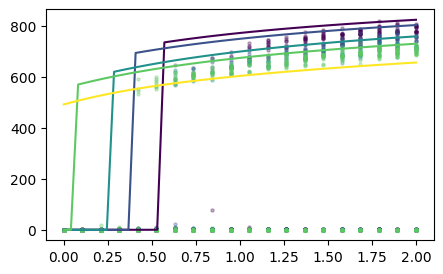

In [20]:
plt.figure(figsize=(5, 3))
cmap = plt.cm.viridis  
colors = cmap(np.linspace(0, 1, len(prevalence_runs)))
lambdas_sim=np.linspace(0.001,2,20)
lambdas = np.linspace(0.001,2,50)

for i in range (len(prevalence_runs)):
    plt.plot(lambdas, prevalence_runs[i],label=f'Varance = {var_s[i]}', color= colors[i])

    for j in range (len(lambdas_sim)):
        plt.scatter([lambdas_sim[j]]*len(prev_sim[i][j]), prev_sim[i][j], color= colors[i], alpha=0.3, s=5)
# Add labels and title+
plt.xlabel(r'$\lambda_1$')
plt.ylabel('Prevalnce')
plt.legend()

In [21]:
prev_mean_sim=[]
for i in range(len(prev_sim)):
    prev=prev_sim[i]
    mean_=[]
    for ii in prev:
        if np.mean(ii)<300:
            mean_.append(0)
        else:
            mean_.append(np.mean(ii))
    prev_mean_sim.append(mean_)



IndexError: list index out of range

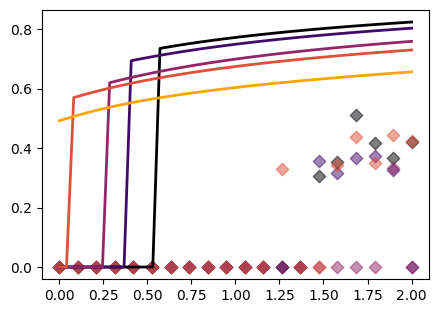

In [22]:
var_s=[10,30,60,100,300]
plt.figure(figsize=(5, 3.5))
cmap = plt.cm.inferno  
colors = cmap(np.linspace(0, 1, len(prevalence_runs)+1))
lambdas_sim=np.linspace(0.001,2,20)
lambdas = np.linspace(0.001,2,50)

for i in  [0,1,2,3,4]:
    plt.plot(lambdas, np.array(prevalence_runs[i])/N,label=f'var = {var_s[i]}', color= colors[i], lw=2)


    plt.scatter(lambdas_sim[0:len(lambdas_sim):1], np.array(prev_mean_sim[i][0:len(lambdas_sim):1])/N, color= colors[i],marker='D', alpha=0.5, s=40)
# Add labels and title
plt.xticks(np.arange(0, 2.1, 0.5), fontsize=12)
plt.yticks(np.arange(0, 0.85, 0.2), fontsize=12)
plt.xlabel(r'$\lambda_1$', fontsize=16)
plt.ylabel(r'$\rho$', fontsize=16)
plt.legend(fontsize=11)

plt.savefig('fig2a.svg')

In [ ]:
np.savetxt('results_data/NB_variance/var_phase_diagram.txt',prevalence_runs)
np.savetxt('results_data/NB_variance/var_phase_diagram_sim.txt',prev_mean_sim)

In [ ]:
print(len(results_perlam2))

In [23]:
k=[5,3]
lambds2=[1,2,3,5,6]

lam1=0.2

var_s_dense=np.linspace(10,30,20)
HO_networks=[]

for var in var_s:
    r=[nb_r(k[0],var),nb_r(k[1],var)]
    p=[nb_p(k[0],var),nb_p(k[1],var)]
    sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
    sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
        
        
        #k=[np.mean(sample_k1),np.var(sample_k1)]
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]
        
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    HO_networks.append([hyper_new,pairs,triples])

mu=1
T=60

iters=60
diff_prev_per_lamb2_var=[]
for lam2 in lambds2:
    aux_prev=[]
    
    for v in range (len(HO_networks)):
        
        hyper_new,pairs,triples = HO_networks[v]
        print(lam1, lam2)
        beta1=lam1*mu/k[0]; beta2=lam2*mu/k[1]
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        prev_2_var=0
        prev_1_var=0
        for i in range(iters):
            para_=[beta1,beta2,mu]
            times, S_t, I_t, Motifs_time= odeint_compact_effective_degree_HO_optimized(para_,hyper_new,T=T,N=N,initial_infected=100,steps_ode=10000,progress_callback=False)
            prev_1_var += I_t[-1]
            times, S_t, I_t2, Motifs_time= odeint_compact_effective_degree_HO_optimized(para_,hyper_new,T=T,N=N,initial_infected=900,steps_ode=10000,progress_callback=False)
            prev_2_var += I_t2[-1]

        prev_2_var=prev_2_var/iters
        prev_1_var=prev_1_var/iters
        print(prev_2_var,prev_1_var)
        aux_prev.append(prev_2_var-prev_1_var)
    
    diff_prev_per_lamb2_var.append(aux_prev)

0.2 1
9.966171733832587e-09 9.96254762180667e-09
0.2 1
9.973455449971867e-09 9.970855630983712e-09
0.2 1
9.979092493601317e-09 9.973899541449529e-09
0.2 1
208.69781428603517 0.00036352164542560484
0.2 1
204.1272557094998 204.12725570949448
0.2 2
9.964906055325735e-09 9.963126640223332e-09
0.2 2
427.23040656681746 9.973962746070038e-09
0.2 2
373.3909034056668 9.975636685796926e-09
0.2 2
394.4109767018853 262.94081732634345
0.2 2
347.4272921039228 347.4272921039181
0.2 3
578.3775249853135 9.96805001950715e-09
0.2 3
576.440522057204 9.970901503854674e-09
0.2 3
505.6678502356442 320.2563051528971
0.2 3
506.22237083534526 506.22237083534105
0.2 3
451.76738992539157 451.7673899253866
0.2 5
754.9653503782393 9.960797305853465e-09
0.2 5
714.709788638652 583.6796607233881
0.2 5
652.2664741442379 652.2664741442308
0.2 5
641.7128749934855 641.7128749934784
0.2 5
591.1281805140059 591.1071065916623
0.2 6
795.1913596824618 9.964083363268422e-09
0.2 6
754.1626750744807 754.1626750744744
0.2 6
697.67

C:\Users\jg3509phd\OneDrive - Northeastern University\Projects\Effective degree\Figures\HO_effective_degree.py:1131: RuntimeWarning: invalid value encountered in scalar subtract
  SS_t[step] = total_links - II_t[step] - SI_t[step]
C:\Users\jg3509phd\OneDrive - Northeastern University\Projects\Effective degree\Figures\HO_effective_degree.py:1136: RuntimeWarning: invalid value encountered in scalar subtract
  SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]


628.0679345653906 638.6938472401808


ValueError: x and y must have same first dimension, but have shapes (20,) and (5,)

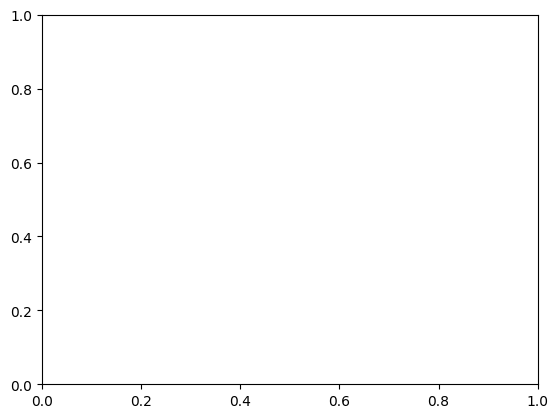

In [25]:
var_s_dense=np.linspace(10,100,20)
for i in range (len(diff_prev_per_lamb2_var)):
    plt.plot(var_s_dense,diff_prev_per_lamb2_var[i],label=lambds2[i],marker='o')

plt.legend()

In [26]:
k=[5,3]
lambdas2=np.linspace(1,6,50)

var_s=[10,40,80]

lam1=1

mu=1
results_perlam2=[]
T=100


prevalence_runs1=[]
prevalence_runs2=[]

for var in var_s:
    r=[nb_r(k[0],var),nb_r(k[1],var)]
    p=[nb_p(k[0],var),nb_p(k[1],var)]
    sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
    sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
    
    print('mean and var of sample')
    print(np.mean(sample_k2),np.var(sample_k2))
    print(np.mean(sample_k1),np.var(sample_k1))
    
    #k=[np.mean(sample_k1),np.var(sample_k1)]
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]
    
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))
    
    prevalence_runs1=[]
    prevalence_runs2=[]
    for lam2 in lambdas2:
        print(f'Lambda2: {lam2}')
        beta1=lam1*mu/k[0]; beta2=lam2*mu/k[1]
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]

        lambdas=np.linspace(0.001,0.8,50)
        
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=100,steps=10000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=900,steps=10000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam2.append([prevalence_runs2,prevalence_runs1])

mean and var of sample
4.021 9.706558999999997
6.119 10.374839
Lambda2: 1.0
Lambda2: 1.1020408163265305
Lambda2: 1.2040816326530612
Lambda2: 1.306122448979592
Lambda2: 1.4081632653061225
Lambda2: 1.510204081632653
Lambda2: 1.6122448979591837
Lambda2: 1.7142857142857144
Lambda2: 1.816326530612245
Lambda2: 1.9183673469387754
Lambda2: 2.020408163265306
Lambda2: 2.122448979591837
Lambda2: 2.2244897959183674
Lambda2: 2.326530612244898
Lambda2: 2.428571428571429
Lambda2: 2.5306122448979593
Lambda2: 2.63265306122449
Lambda2: 2.7346938775510203
Lambda2: 2.836734693877551
Lambda2: 2.938775510204082
Lambda2: 3.0408163265306123
Lambda2: 3.142857142857143
Lambda2: 3.2448979591836737
Lambda2: 3.3469387755102042
Lambda2: 3.4489795918367347
Lambda2: 3.5510204081632653
Lambda2: 3.6530612244897958
Lambda2: 3.7551020408163267
Lambda2: 3.857142857142857
Lambda2: 3.9591836734693877
Lambda2: 4.061224489795919
Lambda2: 4.163265306122449
Lambda2: 4.26530612244898
Lambda2: 4.36734693877551
Lambda2: 4.46938775

In [ ]:
np.savetxt('results_data/NB_variance/heatmap_prev1.txt',prevalence_runs1)
np.savetxt('results_data/NB_variance/heatmap_prev2.txt',prevalence_runs2)
np.savetxt('results_data/NB_variance/heatmap_prev_diff.txt',prevalence_dif)

In [31]:
prevalence_runs2, prevalence_runs1 = results_perlam2[0]
print(len(prevalence_runs2))

10


C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_22956\1259358854.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


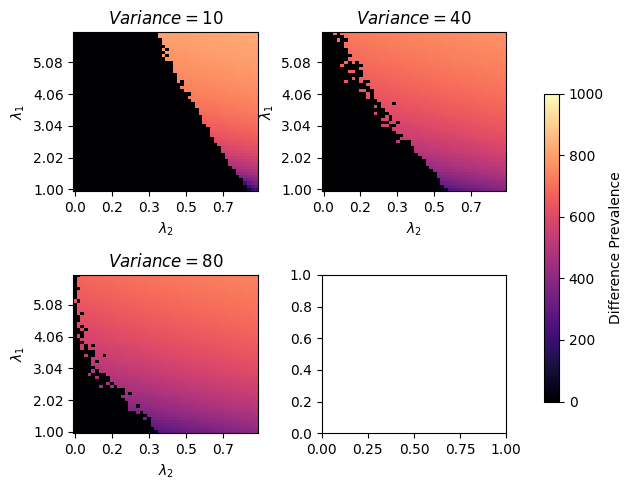

In [39]:
import numpy as np
import matplotlib.pyplot as plt
vmin=0
vmax=N
fig, axs = plt.subplots(2, 2, figsize=(7, 5))
axs = axs.flatten()

# --- 1. Compute all diffs first so we can normalize color scale ---
all_diffs = []
processed_data = []


# --- 2. Plot each subplot ---
for i in range(len(results_perlam2)):
    prevalence_runs1, prevalence_runs1 = results_perlam2[i]

    # Apply mask
    data = prevalence_runs1

    # Colormap with black for NaN
    cmap = plt.cm.magma.copy()

    # Plot heatmap
    im = axs[i].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    # Reduce ticks
    lambda_step = 10
    sigma_step = 10
    axs[i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[i].invert_yaxis()
    # Labels
    axs[i].set_xlabel(r"$\lambda_2$")
    axs[i].set_ylabel(r"$\lambda_1$")
    axs[i].set_title(fr"$Variance = {var_s[i]}$")

# --- 3. Shared colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation="vertical", shrink=0.8,pad=-0.45)
cbar.set_label("Difference Prevalence")

plt.tight_layout()
plt.show()


In [5]:
#####################################################################################################################################################
#####################################################################################################################################################
#####################################################################################################################################################
#####################################################################################################################################################


#Analysis 


#####################################################################################################################################################
#####################################################################################################################################################
#####################################################################################################################################################
#####################################################################################################################################################

In [37]:
prev_mean_sim = np.loadtxt('results_data/NB_variance/var_phase_diagram_sim.txt')
prevalence_runs = np.loadtxt('results_data/NB_variance/var_phase_diagram.txt')

results_perlam2_alt = []

for i in range (len(results_perlam2)):
    prev1 = np.loadtxt(f'results_data/NB_variance/heatmap1_prev1_{i}.txt')
    prev2 = np.loadtxt(f'results_data/NB_variance/heatmap1_prev2_{i}.txt')
    results_perlam2_alt.append([prev1,prev2])

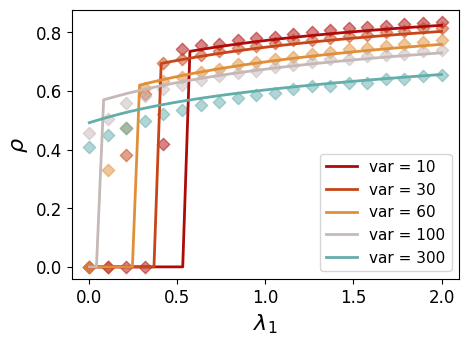

In [29]:
var_s=[10,30,60,100,300]
plt.figure(figsize=(5, 3.5))
colors_1 = ['#ae0a0a', '#c74517', '#e08f39', '#c7b8b8', '#63adab', '#1e6a6a', '#073f40'] 
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
N=1000
cmap = plt.cm.inferno  
colors = cmap(np.linspace(0, 1, len(prevalence_runs)+1))
lambdas_sim=np.linspace(0.001,2,20)
lambdas = np.linspace(0.001,2,50)

for i in  [0,1,2,3,4]:
    plt.plot(lambdas, np.array(prevalence_runs[i])/N,label=f'var = {var_s[i]}', color= colors_1[i], lw=2)


    plt.scatter(lambdas_sim[0:len(lambdas_sim):1], np.array(prev_mean_sim[i][0:len(lambdas_sim):1])/N, color= colors_1[i],marker='D', alpha=0.5, s=40)
# Add labels and title
plt.xticks(np.arange(0, 2.1, 0.5), fontsize=12)
plt.yticks(np.arange(0, 0.85, 0.2), fontsize=12)
plt.xlabel(r'$\lambda_1$', fontsize=16)
plt.ylabel(r'$\rho$', fontsize=16)
plt.legend(fontsize=11)

C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_14224\2006162590.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


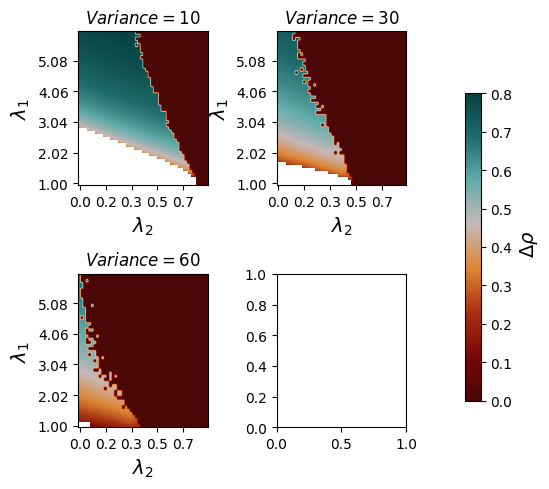

In [38]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
colors_1 = ['#ae0a0a', '#c74517', '#e08f39', '#c7b8b8', '#63adab', '#1e6a6a', '#073f40'] 
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
fig, axs = plt.subplots(2, 2, figsize=(6, 5))
axs = axs.flatten()

# --- 1. Compute all diffs first so we can normalize color scale ---
all_diffs = []
processed_data = []

for i in range(len(results_perlam2_alt)):
    prevalence_runs2, prevalence_runs1 = results_perlam2_alt[i]

    prevalence_runs1 = np.array(prevalence_runs1)
    prevalence_runs2 = np.array(prevalence_runs2)

    prevalence_dif = prevalence_runs2 - prevalence_runs1

    # Replace negative differences with 0
    prevalence_dif = np.where(prevalence_dif < 0, 0, prevalence_dif)

    all_diffs.append(prevalence_dif)
    processed_data.append((prevalence_runs1, prevalence_runs2, prevalence_dif))

vmin = min([np.min(d) for d in all_diffs])/N
vmax = max([np.max(d) for d in all_diffs])/N

# --- 2. Plot each subplot ---
for i in range(len(processed_data)):
    prevalence_runs1, prevalence_runs2, prevalence_dif = processed_data[i]

    # Mask for black cells
    mask = (prevalence_runs1 < 50) & (prevalence_runs2 < 50)

    # Apply mask
    data = prevalence_dif.copy().astype(float)
    data[mask] = np.nan
    data=data/N
    # Colormap with black for NaN
    #cmap = plt.cm.magma.copy()
    #cmap.set_bad(color="gray")
    cmap = cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors_1_ext, N=256)
    # Plot heatmap
    im = axs[i].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    # Reduce ticks
    lambda_step = 10
    sigma_step = 10
    axs[i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]],fontsize=10)
    axs[i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]],fontsize=10)
    axs[i].invert_yaxis()
    # Labels
    axs[i].set_xlabel(r"$\lambda_2$",fontsize=14)

    axs[i].set_ylabel(r"$\lambda_1$",fontsize=14)
    axs[i].set_title(fr"$Variance = {var_s[i]}$")

# --- 3. Shared colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation="vertical", shrink=0.8,pad=-0.5)
cbar.set_label(r" $\Delta \rho$", fontsize=14)

plt.tight_layout()

#plt.savefig('fig2b.svg')
plt.show()


3


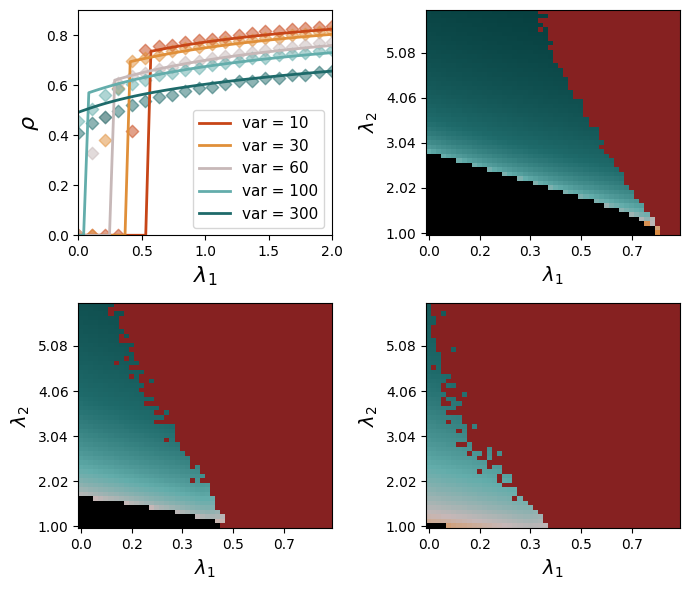

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(7, 6))
axs = axs.flatten()
index=[0,1,2,3]
var_titles=[10,60,80]
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
#colors_1_ext = ['#330A0A','#780808', '#aa3111', '#dd8635' ,'#63adab', '#1f6b6b', '#074040']
#colors_1_ext.reverse()
colors_1_ext=colors_1_ext[3:]
# --- 1. Compute all diffs first so we can normalize color scale ---
all_diffs = []
processed_data = []

for i in range(len(results_perlam2_alt)):
    prevalence_runs2, prevalence_runs1 = results_perlam2_alt[i]

    prevalence_runs1 = np.array(prevalence_runs1)
    prevalence_runs2 = np.array(prevalence_runs2)

    prevalence_dif = prevalence_runs2 - prevalence_runs1

    # Replace negative differences with 0
    prevalence_dif = np.where(prevalence_dif < 0, 0, prevalence_dif)

    all_diffs.append(prevalence_dif)
    processed_data.append((prevalence_runs1, prevalence_runs2, prevalence_dif))
print(len(processed_data))
vmin = min([np.min(d) for d in all_diffs])/N
vmax = max([np.max(d) for d in all_diffs])/N

# --- 2. Plot each subplot ---
for i in range(len(processed_data)+1):
    if i ==0:
        ###############
        
        var_s=[10,30,60,100,300]
        cmap = plt.cm.inferno  
        colors = colors_1[1:]
        lambdas_sim=np.linspace(0.001,2,20)
        lambdas = np.linspace(0.001,2,50)
        
        for j in  [0,1,2,3,4]:
            axs[i].plot(lambdas, np.array(prevalence_runs[j])/N,label=f'var = {var_s[j]}', color= colors[j], lw=2)
            axs[i].scatter(lambdas_sim[0:len(lambdas_sim):1], np.array(prev_mean_sim[j][0:len(lambdas_sim):1])/N, color= colors[j],marker='D', alpha=0.5, s=40)
        # Add labels and title
        #axs[i].set_xticks(np.arange(0, 2.1, 0.5), fontsize=12)
        #axs[i].set_ticks(np.arange(0, 0.85, 0.2), fontsize=12)
        axs[i].set_xlabel(r'$\lambda_1$', fontsize=16)
        axs[i].set_ylabel(r'$\rho$', fontsize=16)
        axs[i].set_xlim((0,2))
        axs[i].set_ylim((0,0.9))
        axs[i].legend(fontsize=11)
        continue

        #################
    prevalence_runs1, prevalence_runs2, prevalence_dif = processed_data[i-1]

    
    lambdas = np.linspace(0.001,0.8,50)
    # Plot heatmap
    mask1 = (prevalence_runs1 < 50) & (prevalence_runs2 < 50)
    mask2 = (prevalence_runs1 > 50) & (prevalence_runs2 > 50) & (prevalence_dif < 50)
    
    # --- create base data for the heatmap ---
    data = prevalence_dif.copy().astype(float)
    data = data / N
    
    # apply mask1 (set to NaN, will appear black or transparent depending on cmap)
    data[mask1] = np.nan
    # Second mask (e.g. a special value to appear as white)
    data[mask2] = -1  # out-of-range value for distinct color
    # Colormap with black for NaN
    #colors_1_ext.reverse()
    cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors_1_ext, N=256)
    cmap.set_bad(color="black")
    cmap.set_under(color="#780808", alpha=0.9) # for out-of-range values (mask2)
    # plot heatmap
    im = axs[i].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto", alpha=1)
    
    # --- OPTIONAL: overlay the second mask in a different color or pattern ---
    # For example, overlay red dots where mask2 is True


    # Reduce ticks
    lambda_step = 10
    sigma_step = 10
    axs[i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]],fontsize=10)
    axs[i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]],fontsize=10)
    axs[i].invert_yaxis()
    # Labels
    #axs[i].set_xlim((0,1.2))
    axs[i].set_xlabel(r"$\lambda_1$",fontsize=14)
    
    axs[i].set_ylabel(r"$\lambda_2$",fontsize=14)
    #axs[i].set_title(fr"$Variance = {var_titles[i-1]}$")

# --- 3. Shared colorbar ---
#cbar = fig.colorbar(im, ax=axs, orientation="vertical", shrink=0.8,pad=-0.5)
cbar.set_label(r" $\Delta \rho$", fontsize=14)

plt.tight_layout()

#plt.savefig('fig2b.svg')
plt.show()


In [36]:
results_perlam2_alt = []

for i in range (len(results_perlam2)):
    prev1 = np.loadtxt(f'results_data/NB_variance/heatmap1_prev1_{i}.txt')
    prev2 = np.loadtxt(f'results_data/NB_variance/heatmap1_prev2_{i}.txt')
    results_perlam2_alt.append([prev1,prev2])

In [34]:

for i in range (len(results_perlam2)):
    np.savetxt(f'results_data/NB_variance/heatmap1_prev1_{i}.txt',results_perlam2[i][0])
    np.savetxt(f'results_data/NB_variance/heatmap1_prev2_{i}.txt',results_perlam2[i][1])

    

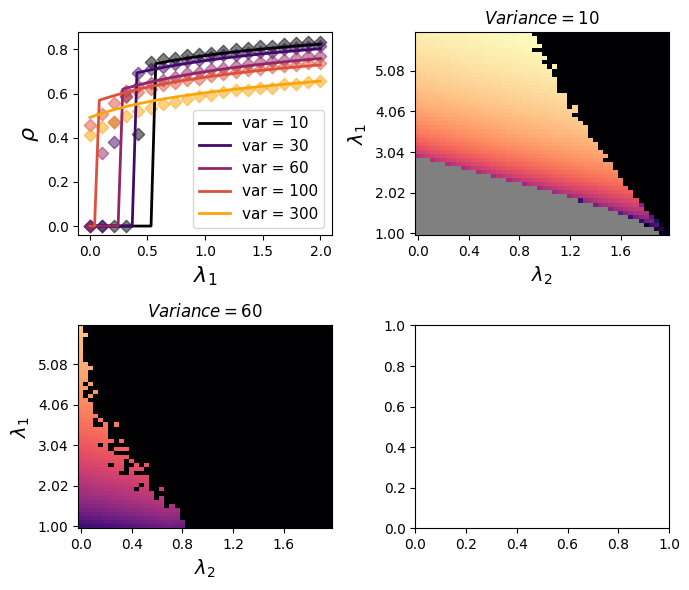

In [33]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(7, 6))
axs = axs.flatten()
index=[0,2,3]
var_titles=[10,60,100]
# --- 1. Compute all diffs first so we can normalize color scale ---
all_diffs = []
processed_data = []

for i in range(len(results_perlam2)):
    prevalence_runs2, prevalence_runs1 = results_perlam2[i]

    prevalence_runs1 = np.array(prevalence_runs1)
    prevalence_runs2 = np.array(prevalence_runs2)

    prevalence_dif = prevalence_runs2 - prevalence_runs1

    # Replace negative differences with 0
    prevalence_dif = np.where(prevalence_dif < 0, 0, prevalence_dif)

    all_diffs.append(prevalence_dif)
    processed_data.append((prevalence_runs1, prevalence_runs2, prevalence_dif))

vmin = min([np.min(d) for d in all_diffs])/N
vmax = max([np.max(d) for d in all_diffs])/N

# --- 2. Plot each subplot ---
for i in range(len(processed_data)):
    if i ==0:
        ###############
        
        var_s=[10,30,60,100,300]
        cmap = plt.cm.inferno  
        colors = cmap(np.linspace(0, 1, len(prevalence_runs)+1))
        lambdas_sim=np.linspace(0.001,2,20)
        lambdas = np.linspace(0.001,2,50)
        
        for j in  [0,1,2,3,4]:
            axs[i].plot(lambdas, np.array(prevalence_runs[j])/N,label=f'var = {var_s[j]}', color= colors[j], lw=2)
            axs[i].scatter(lambdas_sim[0:len(lambdas_sim):1], np.array(prev_mean_sim[j][0:len(lambdas_sim):1])/N, color= colors[j],marker='D', alpha=0.5, s=40)
        # Add labels and title
        #axs[i].set_xticks(np.arange(0, 2.1, 0.5), fontsize=12)
        #axs[i].set_ticks(np.arange(0, 0.85, 0.2), fontsize=12)
        axs[i].set_xlabel(r'$\lambda_1$', fontsize=16)
        axs[i].set_ylabel(r'$\rho$', fontsize=16)
        axs[i].legend(fontsize=11)
        continue

        #################
    prevalence_runs1, prevalence_runs2, prevalence_dif = processed_data[index[i-1]]

    # Mask for black cells
    mask = (prevalence_runs1 < 50) & (prevalence_runs2 < 50)

    # Apply mask
    data = prevalence_dif.copy().astype(float)
    data[mask] = np.nan
    data=data/N
    # Colormap with black for NaN
    cmap = plt.cm.magma.copy()
    cmap.set_bad(color="gray")

    # Plot heatmap
    im = axs[i].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    # Reduce ticks
    lambda_step = 10
    sigma_step = 10
    axs[i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]],fontsize=10)
    axs[i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]],fontsize=10)
    axs[i].invert_yaxis()
    # Labels
    axs[i].set_xlabel(r"$\lambda_2$",fontsize=14)

    axs[i].set_ylabel(r"$\lambda_1$",fontsize=14)
    axs[i].set_title(fr"$Variance = {var_titles[i-1]}$")

# --- 3. Shared colorbar ---
#cbar = fig.colorbar(im, ax=axs, orientation="vertical", shrink=0.8,pad=-0.5)
cbar.set_label(r" $\Delta \rho$", fontsize=14)

plt.tight_layout()

plt.savefig('fig2b.svg')
plt.show()


/tmp/ipykernel_1207916/2712697748.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


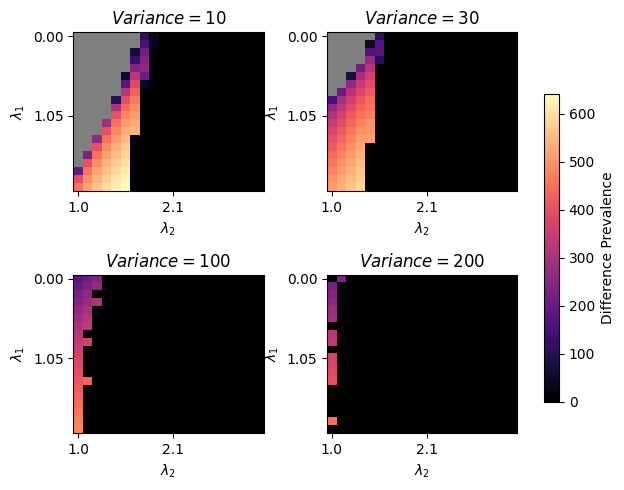

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(7, 5))
axs = axs.flatten()

# --- 1. Compute all diffs first so we can normalize color scale ---
all_diffs = []
processed_data = []

for i in range(len(results_perlam2)):
    prevalence_runs2, prevalence_runs1 = results_perlam2[i]

    prevalence_runs1 = np.array(prevalence_runs1)
    prevalence_runs2 = np.array(prevalence_runs2)

    prevalence_dif = prevalence_runs2 - prevalence_runs1

    # Replace negative differences with 0
    prevalence_dif = np.where(prevalence_dif < 0, 0, prevalence_dif)

    all_diffs.append(prevalence_dif)
    processed_data.append((prevalence_runs1, prevalence_runs2, prevalence_dif))

vmin = min([np.min(d) for d in all_diffs])
vmax = max([np.max(d) for d in all_diffs])

# --- 2. Plot each subplot ---
for i in range(len(processed_data)):
    prevalence_runs1, prevalence_runs2, prevalence_dif = processed_data[i]

    # Mask for black cells
    mask = (prevalence_runs1 < 50) & (prevalence_runs2 < 50)

    # Apply mask
    data = prevalence_dif.copy().astype(float)
    data[mask] = np.nan

    # Colormap with black for NaN
    cmap = plt.cm.magma.copy()
    cmap.set_bad(color="gray")

    # Plot heatmap
    im = axs[i].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    # Reduce ticks
    lambda_step = 10
    sigma_step = 10
    axs[i].set_xticks(np.arange(0, len(lambdas2), sigma_step))
    axs[i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[i].set_xticklabels([f"{s:.1f}" for s in lambdas2[::sigma_step]])
    axs[i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    # Labels
    axs[i].set_xlabel(r"$\lambda_2$")
    axs[i].set_ylabel(r"$\lambda_1$")
    axs[i].set_title(fr"$Variance = {var_s[i]}$")

# --- 3. Shared colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation="vertical", shrink=0.8,pad=-0.45)
cbar.set_label("Difference Prevalence")

plt.tight_layout()
plt.show()



In [12]:

def return_hyper_edges(sample_k1,sample_k2,N,check_conected=True):
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    
    hyper_edges_corr2=[*pairs, *triples]
    hyper_edges_separated_corr2=[pairs, triples]
    attempts=0

    while attempts<100:
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        G = nx.from_edgelist(pairs)

        is_connected = nx.is_connected(G)
        is_connected=True
        
        if check_conected==False: break

        if is_connected: break
        attempts+=1

    if attempts>100:
        print('exceeded attempts')
        return 
    
    hyper_edges=[*pairs, *triples]
        
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    return hyper_edges, pairs, triples




In [13]:
N=1000
k=[3,8]
var=[40,30]

r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
    

sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N)+1
sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
print('')
print(sample_k1[0:5],sample_k1[-5:-1])
print(sample_k2[0:5],sample_k2[-5:-1])

he_uncorr = return_hyper_edges(sample_k1,sample_k2,N,check_conected=False)

sample_k1.sort()
sample_k2.sort()
print('')
print(sample_k1[0:5],sample_k1[-5:-1])
print(sample_k2[0:5],sample_k2[-5:-1])

he_corr1 = return_hyper_edges(sample_k1,sample_k2,N,check_conected=False)

sample_k2[::-1].sort()
print('')
print(sample_k1[0:5],sample_k1[-5:-1])
print(sample_k2[0:5],sample_k2[-5:-1])

he_corr2 = return_hyper_edges(sample_k1,sample_k2,N,check_conected=False)


sample_k1_poi=np.random.poisson(k[0],size=N)+1
sample_k2_poi=np.random.poisson(k[1],size=N)+1
print('')
print(sample_k1_poi[0:5],sample_k1_poi[-5:-1])
print(sample_k2_poi[0:5],sample_k2_poi[-5:-1])

he_poi = return_hyper_edges(sample_k1_poi,sample_k2_poi,N,check_conected=False)

Network_types=[ 'Homo' , 'Hete uncorrelated', 'Hete positive correlated ','Hete negative correlated ']
hyper_edges_list=[he_poi, he_uncorr, he_corr1, he_corr2]


[9 7 5 1 2] [4 6 3 2]
[ 5 22 11 16 15] [ 4  9 17  3]

[1 1 1 1 1] [37 39 49 61]
[1 1 1 1 1] [28 29 30 30]

[1 1 1 1 1] [37 39 49 61]
[30 30 30 29 28] [1 1 1 1]

[3 6 6 6 6] [1 6 4 5]
[ 8 13 14  5 13] [ 8 10  6  8]


In [29]:
k=[5,3]
var_s=[10,30,60,100,500]

#lam1=1
lam2=3

beta1=lam1*mu/k1; beta2=lam2*mu/k2
prevalence_runs=[]

para=[beta1,beta2,mu]

for var in var_s:
    print(f'Variance: {var}')
    
    r=[nb_r(k[0],var),nb_r(k[1],var)]
    p=[nb_p(k[0],var),nb_p(k[1],var)]
    lambdas=np.linspace(0.001,2,50)
    sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
    sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1

    sample_k1.sort()
    sample_k2.sort()
    print('')
    print(sample_k1[0:5],sample_k1[-5:-1])
    print(sample_k2[0:5],sample_k2[-5:-1])

    
    print(np.mean(sample_k2),np.var(sample_k2))
    print(np.mean(sample_k1),np.var(sample_k1))

    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]

    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    para=[1,beta2,k[0],k[1],mu]
    prevalence= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=100,steps=10000)
    
    prevalence_runs.append(prevalence)

Variance: 10

[1 1 1 1 1] [17 18 18 18]
[1 1 1 1 1] [15 16 16 18]
3.751 8.340999000000002
6.13 9.9111
Variance: 30

[1 1 1 1 1] [28 29 31 32]
[1 1 1 1 1] [27 32 33 38]
3.755 21.736975
5.814 28.431404
Variance: 60

[1 1 1 1 1] [54 59 60 68]
[1 1 1 1 1] [44 47 50 56]
3.569 47.927239
6.036 63.894704000000004
Variance: 100

[1 1 1 1 1] [62 67 78 85]
[1 1 1 1 1] [57 58 63 67]
4.05 78.9895
5.591 89.073719
Variance: 500

[1 1 1 1 1] [120 122 132 189]
[1 1 1 1 1] [141 187 234 259]
4.114 393.98700399999996
5.636 323.157504


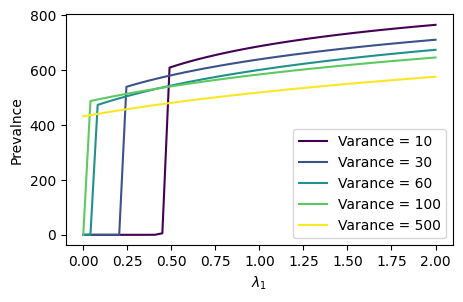

In [30]:
cmap = plt.cm.viridis  
colors = cmap(np.linspace(0, 1, len(prevalence_runs)))

plt.figure(figsize=(5, 3))
for i in range (len(prevalence_runs)):
    plt.plot(lambdas, prevalence_runs[i],label=f'Varance = {var_s[i]}', color= colors[i])

# Add labels and title
plt.xlabel(r'$\lambda_1$')
plt.ylabel('Prevalnce')
plt.legend()
    


In [20]:
k=[5,3]
bins=30
lambdas2=[0,1,3,10]
var_s=np.linspace(6,100,bins)

#lam1=1


all_prev_results=[]

results_perlam1=[]

prevalence_runs1=[]
prevalence_runs2=[]

para=[beta1,beta2,mu]
for lam2 in lambdas2:
    prevalence_runs1=[]
    prevalence_runs2=[]
    for var in var_s:
        print(f'Variance: {var}')
        beta1=lam1*mu/k1; beta2=lam2*mu/k2
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        lambdas=np.linspace(0.001,2,bins)
        sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
        sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1

        
        print(np.mean(sample_k2),np.var(sample_k2))
        print(np.mean(sample_k1),np.var(sample_k1))
    
        
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        hyper_edges=[*pairs, *triples]
    
        hyper_new=[]
        for edges in hyper_edges:
            new_edge=[]
            for ele in edges:
                new_edge.append(int(ele+1))
            hyper_new.append(np.array(new_edge))
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=50,steps=20000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=950,steps=20000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam1.append([prevalence_runs2,prevalence_runs1])


all_prev_results.append(results_perlam1)

Variance: 6.0
4.141 5.891119000000001
5.987 5.610831
Variance: 9.241379310344827
3.943 8.907751000000001
5.995 8.910974999999999
Variance: 12.482758620689655
3.96 10.874399999999998
5.842 11.169036
Variance: 15.724137931034482
4.166 17.540444000000004
6.198 16.736796000000002
Variance: 18.96551724137931
4.054 18.127084
5.914 16.990603999999998
Variance: 22.206896551724135
4.027 22.370271
5.887 22.692231
Variance: 25.448275862068964
3.987 25.898830999999998
5.804 22.699583999999998
Variance: 28.689655172413794
3.895 26.759974999999997
5.948 27.827296
Variance: 31.93103448275862
3.677 28.290671000000003
5.777 30.987271
Variance: 35.172413793103445
4.305 46.55997500000001
5.961 37.78947900000001
Variance: 38.41379310344827
4.085 46.663775
5.971 36.246159
Variance: 41.6551724137931
4.468 47.29097599999999
5.604 32.231184000000006
Variance: 44.89655172413793
4.035 42.423775
5.665 34.88877500000001
Variance: 48.137931034482754
4.149 57.666799
5.803 45.060190999999996
Variance: 51.37931034482

In [102]:
k=[5,3]
bins=30
lambdas2=[0,1,3,10]
var_s=np.linspace(6,100,bins)


#lam1=1


results_perlam2=[]



prevalence_runs1=[]
prevalence_runs2=[]

para=[beta1,beta2,mu]
for lam2 in lambdas2:
    prevalence_runs1=[]
    prevalence_runs2=[]
    for var in var_s:
        print(f'Variance: {var}')
        beta1=lam1*mu/k1; beta2=lam2*mu/k2
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        lambdas=np.linspace(0.001,2,bins)
        sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
        sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1

        sample_k1.sort()
        sample_k2.sort()
        print('')
        print(sample_k1[0:5],sample_k1[-5:-1])
        print(sample_k2[0:5],sample_k2[-5:-1])

        print(np.mean(sample_k2),np.var(sample_k2))
        print(np.mean(sample_k1),np.var(sample_k1))
    
        
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        hyper_edges=[*pairs, *triples]
    
        hyper_new=[]
        for edges in hyper_edges:
            new_edge=[]
            for ele in edges:
                new_edge.append(int(ele+1))
            hyper_new.append(np.array(new_edge))
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=50,steps=20000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=950,steps=20000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam2.append([prevalence_runs2,prevalence_runs1])



all_prev_results.append(results_perlam2)

Variance: 6.0

[1 1 1 1 1] [14 15 15 15]
[1 1 1 1 1] [12 12 13 13]
4.015 5.358775
6.109 6.507119
Variance: 9.241379310344827

[1 1 1 1 1] [16 16 16 20]
[1 1 1 1 1] [16 17 18 19]
3.924 8.522224000000001
5.953 8.854791
Variance: 12.482758620689655

[1 1 1 1 1] [19 21 22 22]
[1 1 1 1 1] [23 23 23 25]
4.086 15.336604000000001
5.964 13.008704000000002
Variance: 15.724137931034482

[1 1 1 1 1] [22 22 23 24]
[1 1 1 1 1] [19 20 20 22]
3.834 13.126444000000001
5.961 15.461479
Variance: 18.96551724137931

[1 1 1 1 1] [23 24 25 25]
[1 1 1 1 1] [23 23 25 32]
3.929 17.297959000000002
6.086 18.346604
Variance: 22.206896551724135

[1 1 1 1 1] [24 25 27 27]
[1 1 1 1 1] [27 29 34 36]
4.021 22.350558999999997
5.927 22.309670999999998
Variance: 25.448275862068964

[1 1 1 1 1] [26 27 27 31]
[1 1 1 1 1] [31 32 34 35]
3.947 22.552191
5.58 22.8416
Variance: 28.689655172413794

[1 1 1 1 1] [31 31 31 35]
[1 1 1 1 1] [35 39 40 42]
3.638 25.084956
6.31 29.0199
Variance: 31.93103448275862

[1 1 1 1 1] [31 33 38 4

In [103]:
k=[5,3]
lambdas2=[0,1,3,10]
var_s=np.linspace(6,100,30)

#lam1=1


results_perlam3=[]



prevalence_runs1=[]
prevalence_runs2=[]

para=[beta1,beta2,mu]
for lam2 in lambdas2:
    prevalence_runs1=[]
    prevalence_runs2=[]
    for var in var_s:
        print(f'Variance: {var}')
        beta1=lam1*mu/k1; beta2=lam2*mu/k2
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        lambdas=np.linspace(0.001,2,30)
        sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
        sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1

        sample_k1.sort()
        sample_k2.sort()
        sample_k2[::-1].sort()
        print('')
        print(sample_k1[0:5],sample_k1[-5:-1])
        print(sample_k2[0:5],sample_k2[-5:-1])

        
        print(np.mean(sample_k2),np.var(sample_k2))
        print(np.mean(sample_k1),np.var(sample_k1))
            
        
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        hyper_edges=[*pairs, *triples]
    
        hyper_new=[]
        for edges in hyper_edges:
            new_edge=[]
            for ele in edges:
                new_edge.append(int(ele+1))
            hyper_new.append(np.array(new_edge))
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=50,steps=20000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=950,steps=20000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam3.append([prevalence_runs2,prevalence_runs1])


all_prev_results.append(results_perlam3)

Variance: 6.0

[1 1 1 1 1] [14 14 15 15]
[14 13 13 12 12] [1 1 1 1]
3.975 5.532375
5.937 5.801031000000001
Variance: 9.241379310344827

[1 1 1 1 1] [16 16 17 18]
[27 19 19 17 16] [1 1 1 1]
3.882 9.208076000000002
5.953 9.008791
Variance: 12.482758620689655

[1 1 1 1 1] [20 20 21 21]
[24 24 22 21 20] [1 1 1 1]
4.075 13.553375
6.154 13.160284
Variance: 15.724137931034482

[1 1 1 1 1] [22 23 23 24]
[27 27 27 25 24] [1 1 1 1]
4.074 16.620523999999996
5.908 16.399536
Variance: 18.96551724137931

[1 1 1 1 1] [30 33 33 33]
[32 28 28 21 21] [1 1 1 1]
3.716 14.177344
6.195 22.490975
Variance: 22.206896551724135

[1 1 1 1 1] [22 23 23 25]
[42 36 34 33 33] [1 1 1 1]
4.178 23.820315999999995
5.777 18.805270999999998
Variance: 25.448275862068964

[1 1 1 1 1] [27 29 34 35]
[43 36 32 32 31] [1 1 1 1]
4.051 25.816398999999993
6.377 27.494871
Variance: 28.689655172413794

[1 1 1 1 1] [34 34 39 40]
[44 38 32 32 30] [1 1 1 1]
4.135 27.838775000000002
6.353 33.524390999999994
Variance: 31.93103448275862



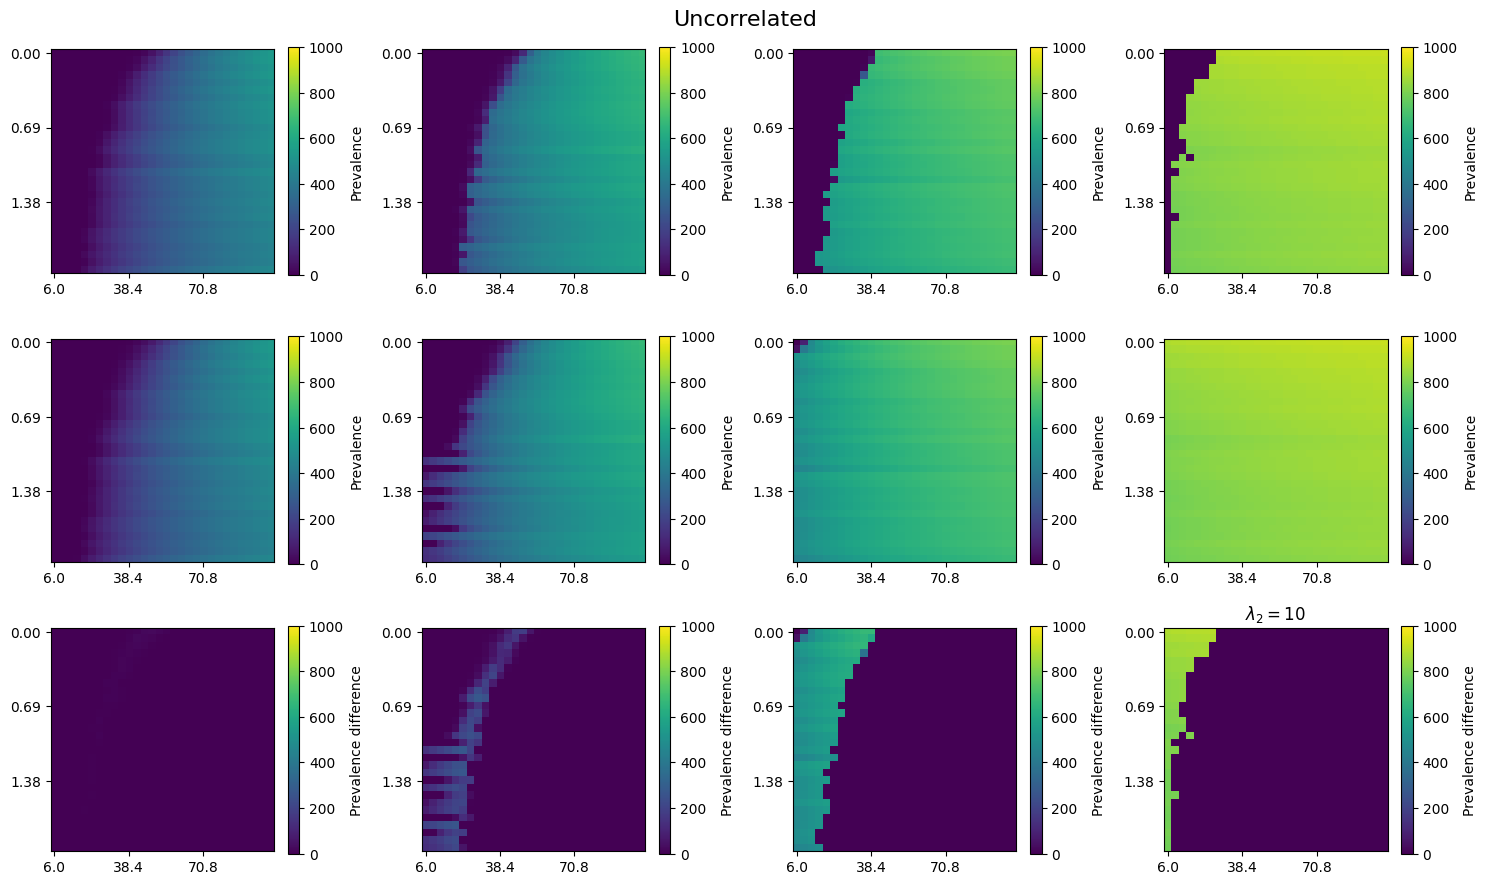

In [107]:

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
presults = all_prev_results[0]
fig.suptitle("Uncorrelated", fontsize=16)
row=0
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)
    
    plt.title(rf'$\lambda_2 = {lambdas2[i]}$')
    data = np.array(prevalence_runs1)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=1
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_runs2)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=2
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_dif)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence difference")

plt.tight_layout()

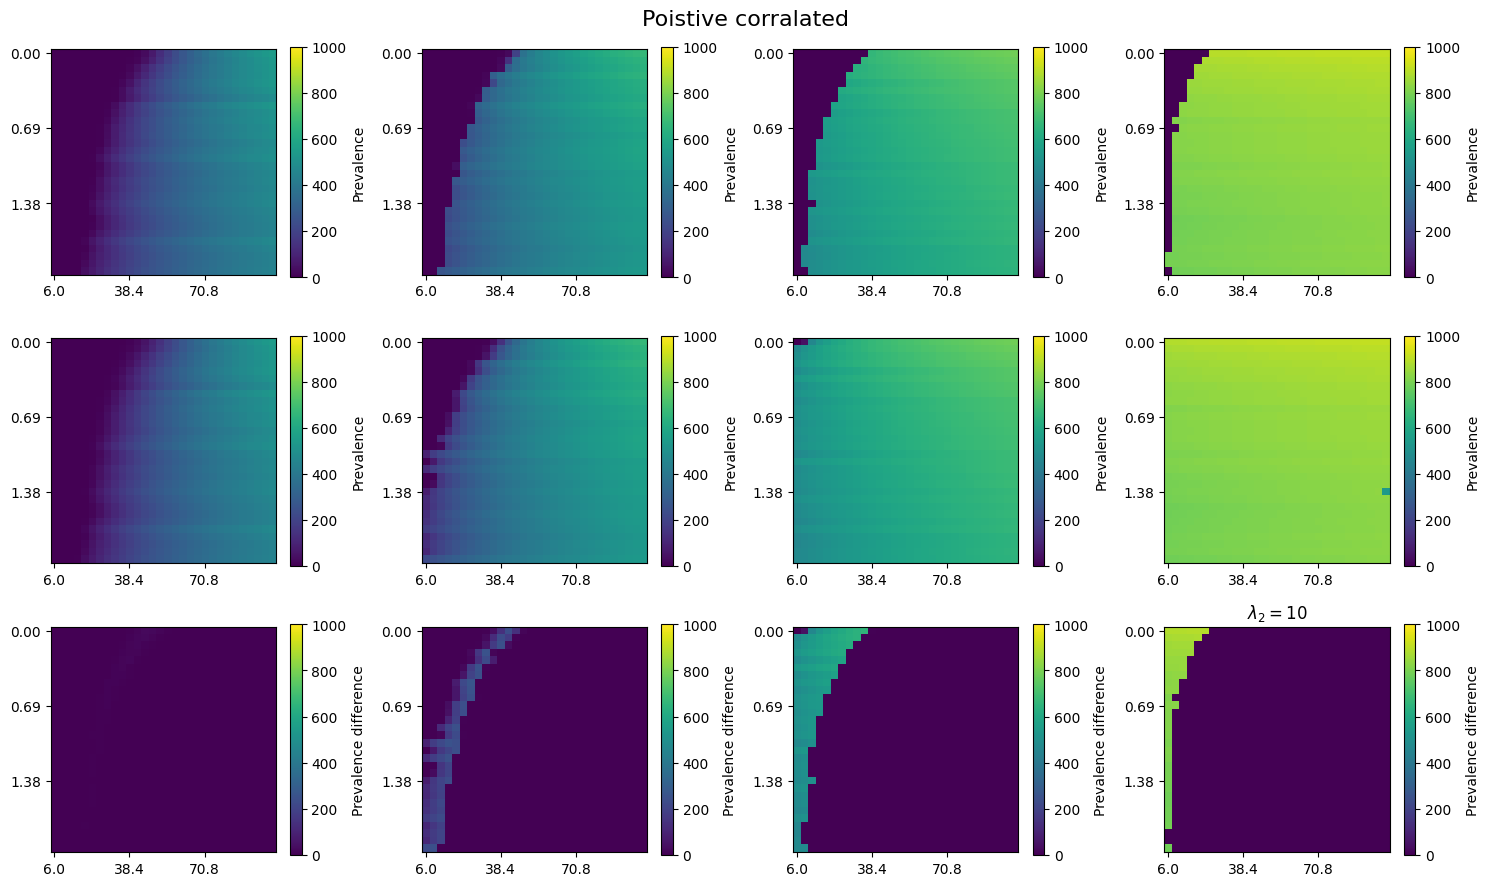

In [108]:

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
presults = all_prev_results[1]
fig.suptitle("Poistive corralated", fontsize=16)
row=0
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)
    
    plt.title(rf'$\lambda_2 = {lambdas2[i]}$')
    data = np.array(prevalence_runs1)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis",vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=1
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_runs2)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=2
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_dif)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence difference")

plt.tight_layout()
plt.tight_layout()

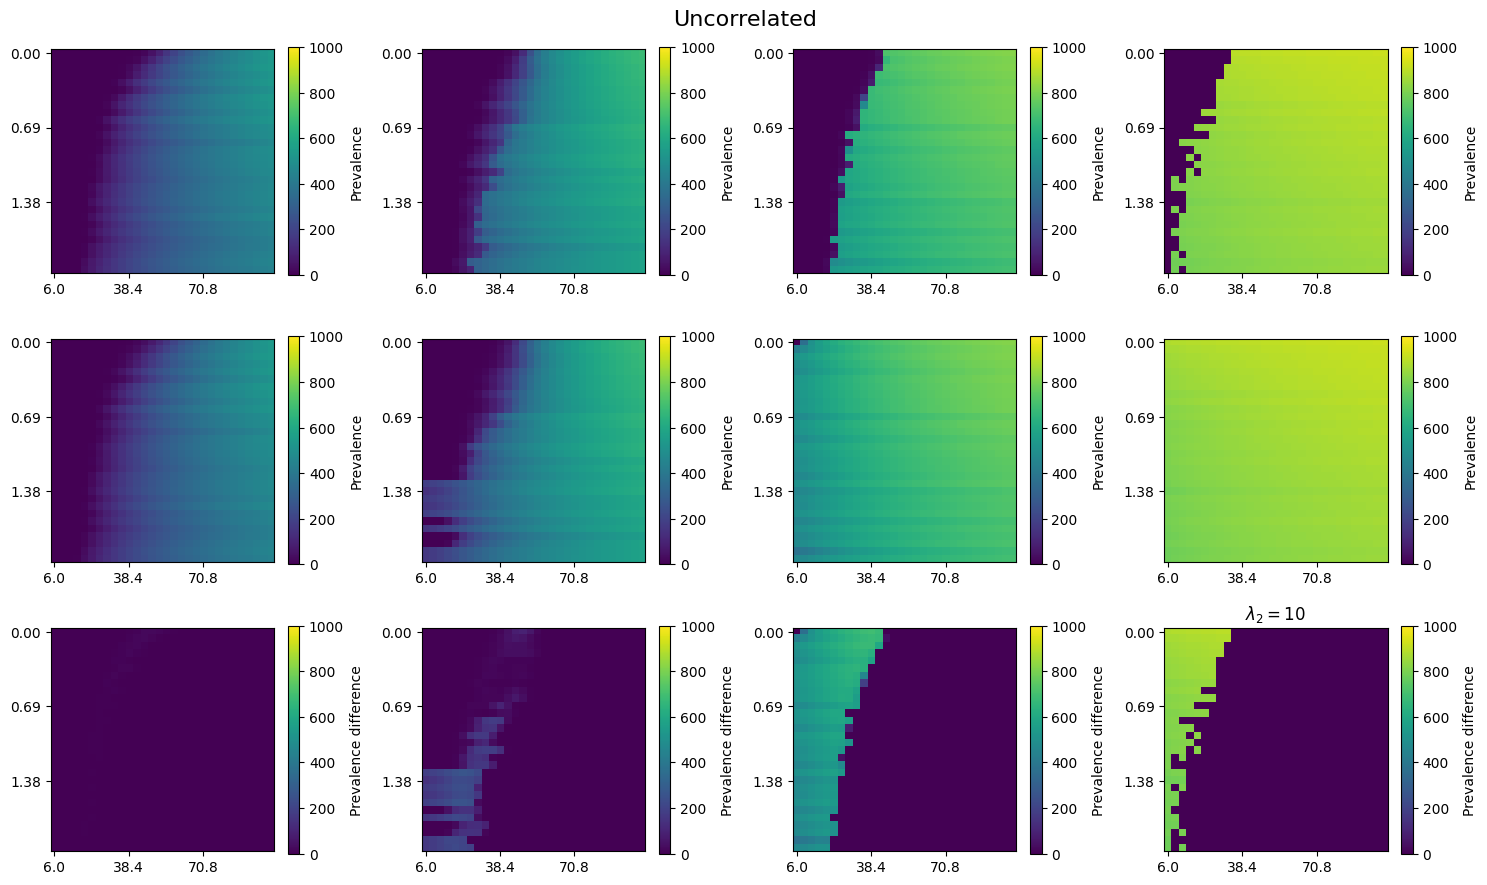

In [109]:

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
presults = all_prev_results[2]
fig.suptitle("Uncorrelated", fontsize=16)
row=0
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)
    
    plt.title(rf'$\lambda_2 = {lambdas2[i]}$')
    data = np.array(prevalence_runs1)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=1
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_runs2)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis",vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=2
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_dif)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = 10   # show every 2nd lambda
    sigma_step = 10    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(var_s), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in var_s[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas[::lambda_step]])

    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence difference")

plt.tight_layout()

In [154]:
k=[6,6]
var_s=[10,50,100,500]
lambdas2=np.linspace(0,8,30)

#lam1=1

all_prev_results_var=[]
results_perlam1=[]



prevalence_runs1=[]
prevalence_runs2=[]

para=[beta1,beta2,mu]
for var in var_s:
    prevalence_runs1=[]
    prevalence_runs2=[]
    for lam2 in lambdas2:
        print(f'Variance: {var}')
        beta1=lam1*mu/k1; beta2=lam2*mu/k2
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        lambdas=np.linspace(0.001,1.3,30)
        sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
        sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
        
        print(np.mean(sample_k2),np.var(sample_k2))
        print(np.mean(sample_k1),np.var(sample_k1))
            
        
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        hyper_edges=[*pairs, *triples]
    
        hyper_new=[]
        for edges in hyper_edges:
            new_edge=[]
            for ele in edges:
                new_edge.append(int(ele+1))
            hyper_new.append(np.array(new_edge))
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=50,steps=20000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=950,steps=20000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam1.append([prevalence_runs2,prevalence_runs1])


all_prev_results_var.append(results_perlam1)

Variance: 10
6.92 9.7576
7.009 9.940918999999997
Variance: 10
7.021 10.072559
7.137 10.494231
Variance: 10
6.994 9.817963999999998
7.064 9.715904
Variance: 10
6.929 9.253959
7.001 9.808999
Variance: 10
7.111 10.846679
6.974 9.969324
Variance: 10
7.095 10.379975000000002
6.92 9.765600000000001
Variance: 10
6.889 9.896679
6.965 9.883775
Variance: 10
6.977 10.520470999999999
6.97 9.719100000000001
Variance: 10
6.954 9.741883999999999
7.048 10.405696
Variance: 10
6.872 9.947615999999998
6.859 9.219119
Variance: 10
6.896 9.309184000000002
7.025 10.462375
Variance: 10
6.965 10.435775000000001
6.888 10.563456
Variance: 10
7.045 9.710975000000001
6.982 10.013676000000002
Variance: 10
6.849 10.526199
7.04 9.9524
Variance: 10
7.158 9.925036
7.008 10.529936
Variance: 10
7.057 9.771751
6.866 9.456043999999999
Variance: 10
6.915 10.197775000000002
6.903 8.899591000000001
Variance: 10
6.96 9.5504
6.913 10.393431
Variance: 10
6.957 9.783151
7.081 10.758439000000001
Variance: 10
7.068 10.103376
7.049 

/home/jupyter-aguzman/Effective_Degree/Heterogenity_effect/HO_effective_degree.py:1131: RuntimeWarning: invalid value encountered in scalar subtract
  SS_t[step] = total_links - II_t[step] - SI_t[step]
/home/jupyter-aguzman/Effective_Degree/Heterogenity_effect/HO_effective_degree.py:1136: RuntimeWarning: invalid value encountered in scalar subtract
  SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]


Infection died out, terminating early
Variance: 500
6.534 424.634844
6.414 443.72460400000006
Variance: 500
7.048 424.255696
6.216 346.18534400000004
Variance: 500
6.682 602.7228760000002
7.332 513.4317760000001
Variance: 500
5.405 235.03697499999998
5.416 247.26094400000002
Variance: 500
7.021 447.462559
6.404 424.5747839999999
Variance: 500
6.875 421.771375
6.94 592.2124
Variance: 500
5.563 356.0680310000001
6.969 390.056039
Variance: 500
7.495 574.117975
6.98 746.7316000000001
Variance: 500
6.639 441.53267900000003
7.133 396.96731100000005
Variance: 500
6.591 493.27771900000005
6.95 465.2575


In [155]:
k=[6,6]
var_s=[10,50,100,500]
lambdas2=np.linspace(0,8,30)

#lam1=1

results_perlam1=[]



prevalence_runs1=[]
prevalence_runs2=[]

para=[beta1,beta2,mu]
for var in var_s:
    prevalence_runs1=[]
    prevalence_runs2=[]
    for lam2 in lambdas2:
        print(f'Variance: {var}')
        beta1=lam1*mu/k1; beta2=lam2*mu/k2
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        lambdas=np.linspace(0.001,1.3,30)
        sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
        sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1


        sample_k1.sort()
        sample_k2.sort()
        print('')
        print(sample_k1[0:5],sample_k1[-5:-1])
        print(sample_k2[0:5],sample_k2[-5:-1])

        print(np.mean(sample_k2),np.var(sample_k2))
        print(np.mean(sample_k1),np.var(sample_k1))
            
        
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        hyper_edges=[*pairs, *triples]
    
        hyper_new=[]
        for edges in hyper_edges:
            new_edge=[]
            for ele in edges:
                new_edge.append(int(ele+1))
            hyper_new.append(np.array(new_edge))
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=50,steps=20000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=950,steps=20000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam1.append([prevalence_runs2,prevalence_runs1])


all_prev_results_var.append(results_perlam1)

Variance: 10

[1 1 1 1 1] [17 19 20 20]
[1 1 1 1 1] [17 17 18 18]
7.066 9.549644
7.057 10.713751
Variance: 10

[1 1 1 1 1] [18 18 20 20]
[1 1 1 1 1] [19 19 20 21]
6.961 10.699479000000004
6.921 9.750759
Variance: 10

[1 1 1 1 1] [16 17 17 18]
[1 1 1 1 1] [18 18 19 20]
6.976 10.507424
7.035 9.511775
Variance: 10

[1 1 1 1 1] [17 18 19 19]
[1 1 1 1 1] [17 18 18 19]
7.141 10.631118999999998
6.874 9.840124
Variance: 10

[1 1 1 1 1] [16 16 17 18]
[1 1 1 1 1] [17 17 19 20]
6.912 9.914255999999998
6.906 9.235164
Variance: 10

[1 1 1 1 1] [17 17 18 19]
[1 1 1 1 1] [17 17 17 17]
6.831 8.944439
6.899 9.122798999999999
Variance: 10

[1 1 1 1 1] [17 17 18 20]
[1 1 1 1 1] [17 17 18 18]
6.897 9.662391
6.917 9.494110999999998
Variance: 10

[1 1 1 1 1] [16 17 17 20]
[1 1 1 1 1] [17 18 18 22]
6.939 10.189278999999999
6.692 9.453135999999999
Variance: 10

[1 1 1 1 1] [16 16 18 20]
[1 1 1 1 1] [17 17 17 18]
7.004 10.029984
6.963 10.167631000000002
Variance: 10

[1 1 1 1 1] [17 18 18 20]
[1 1 1 2 2] [16 1

In [156]:
k=[6,6]
var_s=[10,50,100,500]
lambdas2=np.linspace(0,8,30)

#lam1=1

results_perlam1=[]



prevalence_runs1=[]
prevalence_runs2=[]

para=[beta1,beta2,mu]
for var in var_s:
    prevalence_runs1=[]
    prevalence_runs2=[]
    for lam2 in lambdas2:
        print(f'Variance: {var}')
        beta1=lam1*mu/k1; beta2=lam2*mu/k2
        r=[nb_r(k[0],var),nb_r(k[1],var)]
        p=[nb_p(k[0],var),nb_p(k[1],var)]
        lambdas=np.linspace(0.001,1.3,30)
        sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N) +1
        sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1


        sample_k1.sort()
        sample_k2.sort()
        sample_k2[::-1].sort()
        print('')
        print(sample_k1[0:5],sample_k1[-5:-1])
        print(sample_k2[0:5],sample_k2[-5:-1])

        print(np.mean(sample_k2),np.var(sample_k2))
        print(np.mean(sample_k1),np.var(sample_k1))
            
        
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        hyper_edges=[*pairs, *triples]
    
        hyper_new=[]
        for edges in hyper_edges:
            new_edge=[]
            for ele in edges:
                new_edge.append(int(ele+1))
            hyper_new.append(np.array(new_edge))
    
        para=[1,beta2,k[0],k[1],mu]
        prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=50,steps=20000)
        prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=950,steps=20000)
        
        prevalence_runs2.append(prevalence2)
        prevalence_runs1.append(prevalence1)

    results_perlam1.append([prevalence_runs2,prevalence_runs1])


all_prev_results_var.append(results_perlam1)

Variance: 10

[1 1 1 1 1] [18 18 18 18]
[20 20 19 19 18] [1 1 1 1]
7.09 10.181899999999999
7.042 10.156236000000002
Variance: 10

[1 1 1 1 1] [17 17 18 19]
[24 22 21 19 18] [1 1 1 1]
7.015 10.108775000000001
7.024 9.451424000000001
Variance: 10

[1 1 1 1 1] [16 17 18 18]
[20 19 18 18 17] [1 1 1 1]
6.95 9.8535
7.112 10.413456
Variance: 10

[1 1 1 1 1] [17 17 18 18]
[18 17 17 17 17] [1 1 1 1]
6.963 9.993631
7.081 9.378439000000002
Variance: 10

[1 1 1 1 1] [17 17 17 18]
[21 20 19 19 18] [1 1 1 1]
6.923 10.247071000000002
7.042 10.096236
Variance: 10

[1 1 1 1 1] [17 18 18 18]
[20 19 19 19 18] [1 1 1 1]
7.022 10.173516000000001
7.049 10.414599000000003
Variance: 10

[1 1 1 1 1] [18 18 18 19]
[21 20 20 19 17] [1 1 1 1]
7.174 9.421724000000001
7.103 10.230391
Variance: 10

[1 1 1 1 1] [17 17 19 19]
[20 20 20 19 18] [2 2 1 1]
7.096 9.700784
7.005 10.054975000000002
Variance: 10

[1 1 1 1 1] [17 19 20 20]
[20 20 20 20 19] [1 1 1 1]
7.121 10.836359
7.016 9.717743999999998
Variance: 10

[1 1 1 

In [139]:
lambdas2=np.linspace(0,8,30)

print(len(lambdas2))

30


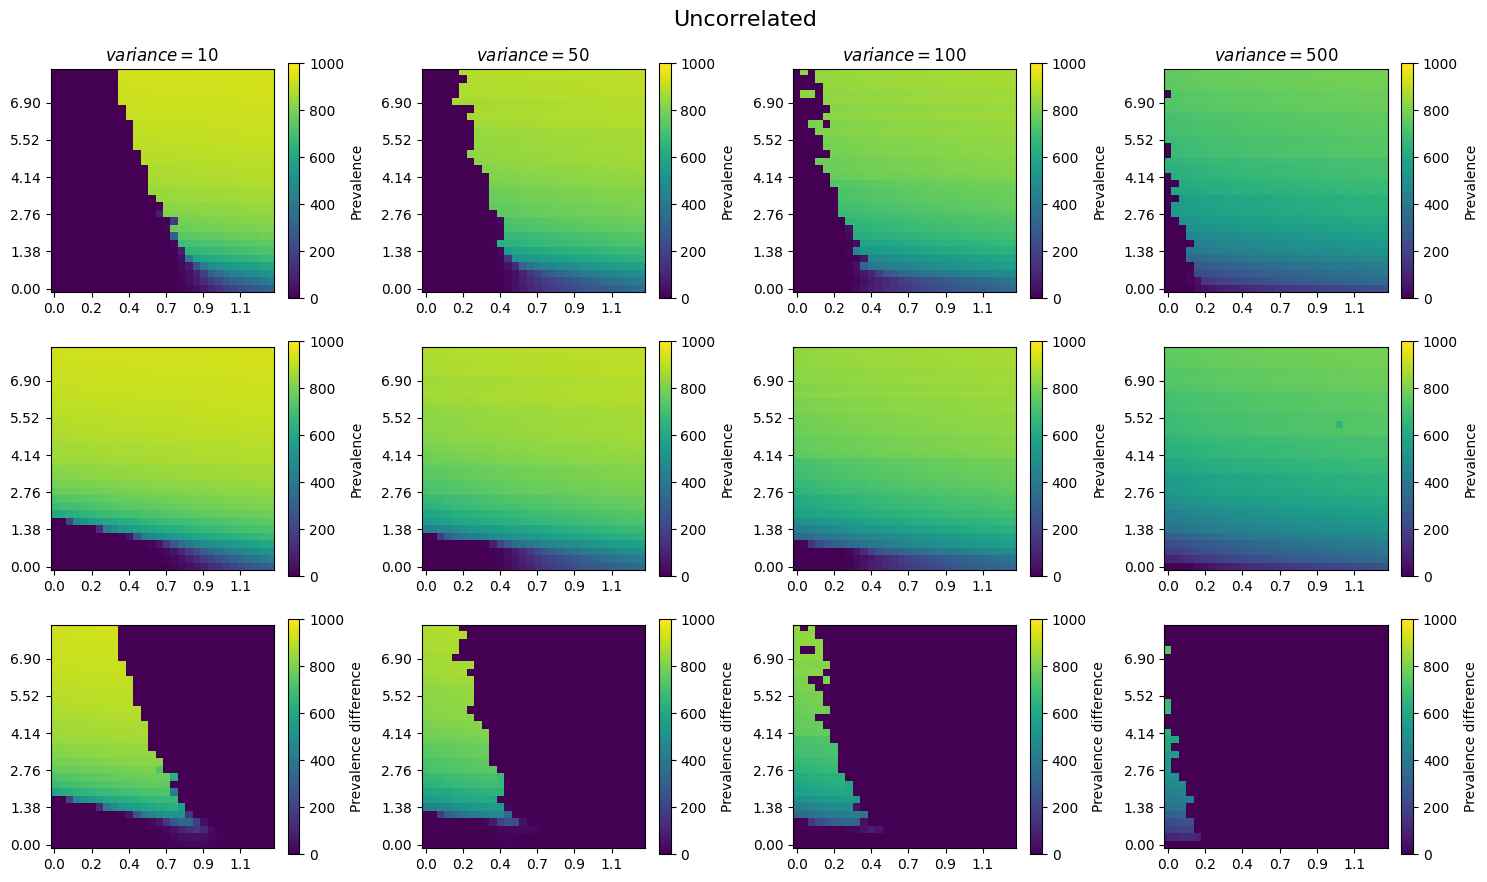

In [159]:

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
presults = all_prev_results_var[0]
fig.suptitle("Uncorrelated", fontsize=16)
row=0
nth=5
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)
    
    axs[row,i].set_title(rf'$variance = {var_s[i]}$')
    data = np.array(prevalence_runs1)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step =nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=1
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_runs2)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=2
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_dif)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence difference")

plt.tight_layout()

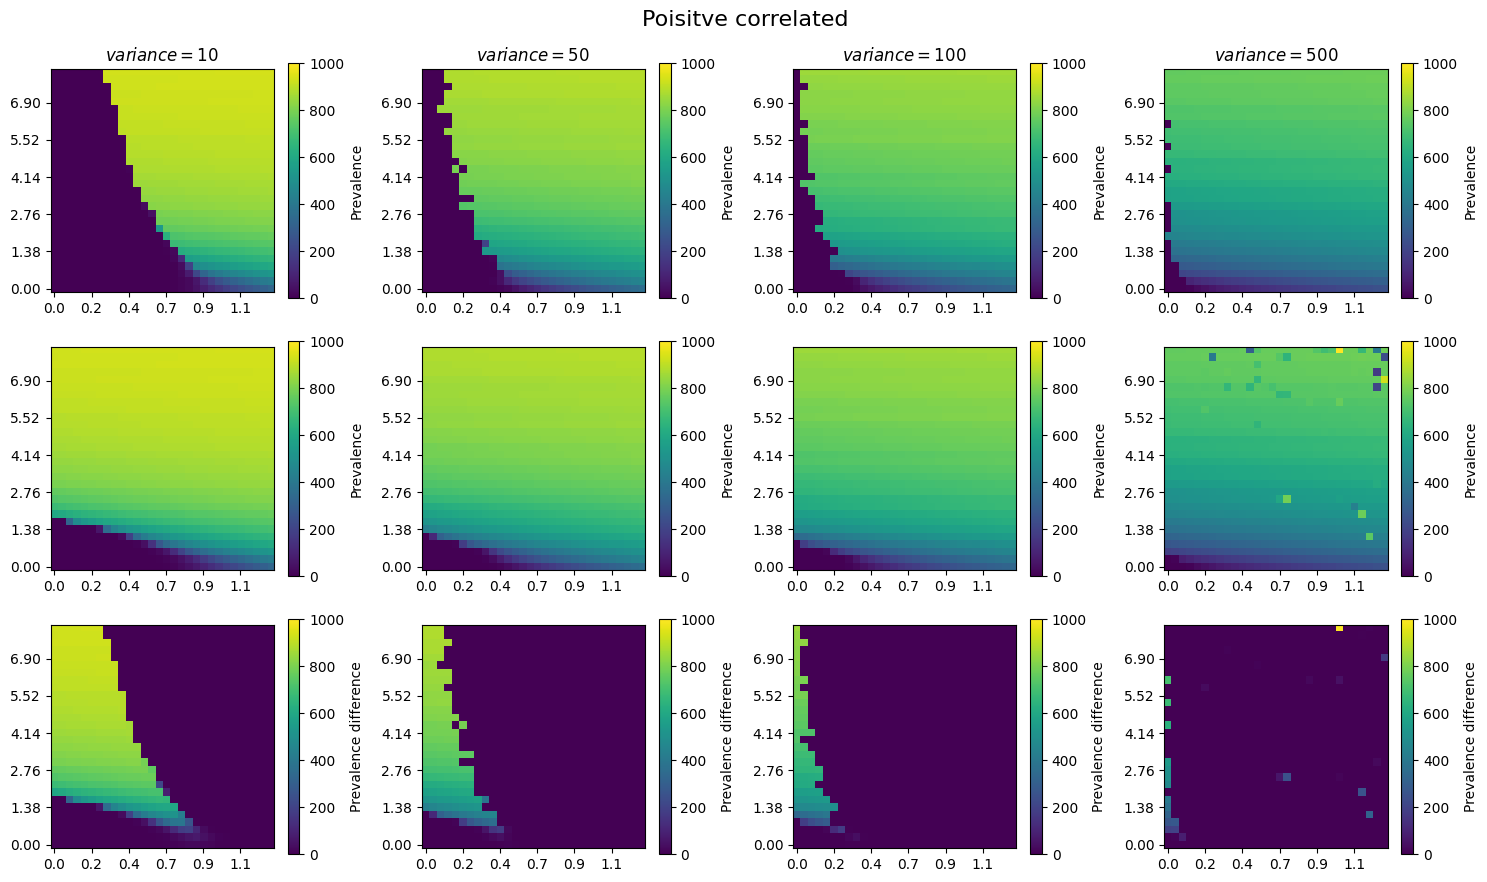

In [160]:

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
presults = all_prev_results_var[1]
fig.suptitle("Poisitve correlated", fontsize=16)
row=0
nth=5
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)
    
    axs[row,i].set_title(rf'$variance = {var_s[i]}$')
    data = np.array(prevalence_runs1)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step =nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=1
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_runs2)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=2
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_dif)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence difference")

plt.tight_layout()

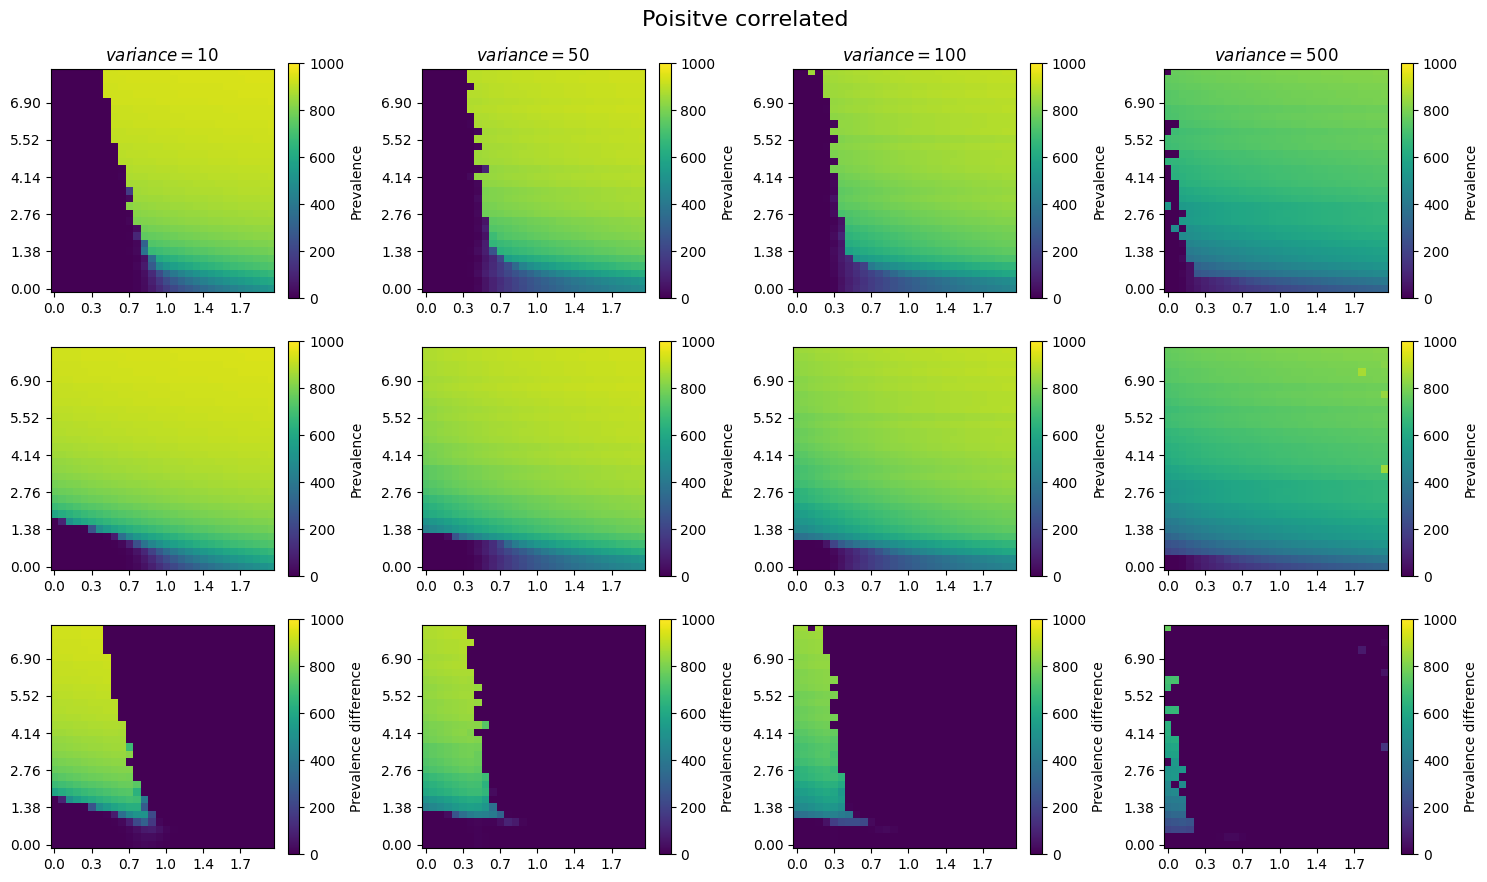

In [153]:

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
presults = all_prev_results_var[2]
fig.suptitle("Poisitve correlated", fontsize=16)
row=0
nth=5
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)
    
    axs[row,i].set_title(rf'$variance = {var_s[i]}$')
    data = np.array(prevalence_runs1)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step =nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=1
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_runs2)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence")


row=2
for i in range (len(all_prev_results[1])):
    prevalence_runs2,prevalence_runs1 = presults[i]
    prevalence_dif=np.array(prevalence_runs2)-np.array(prevalence_runs1)

    data = np.array(prevalence_dif)
    
    # Create heatmap
    im = axs[row,i].imshow(data, cmap="viridis", vmin=0, vmax=1000)
    
    # Set ticks
    lambda_step = nth   # show every 2nd lambda
    sigma_step = nth    # show every 3rd sigma
    
    axs[row,i].set_xticks(np.arange(0, len(lambdas), sigma_step))
    axs[row,i].set_yticks(np.arange(0, len(lambdas2), lambda_step))
    axs[row,i].set_xticklabels([f"{s:.1f}" for s in lambdas[::sigma_step]])
    axs[row,i].set_yticklabels([f"{l:.2f}" for l in lambdas2[::lambda_step]])
    axs[row,i].invert_yaxis()
    cbar = plt.colorbar(im)
    cbar.set_label("Prevalence difference")

plt.tight_layout()